====数据基本信息====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   machine_speed_rpm     1000 non-null   int32
 1   humidity_percent      1000 non-null   int32
 2   production_count      1000 non-null   int32
 3   defect_count          1000 non-null   int32
 4   maintenance_required  1000 non-null   int32
dtypes: int32(5)
memory usage: 19.7 KB
None

====描述性统计====
       machine_speed_rpm  humidity_percent  production_count  defect_count  \
count        1000.000000       1000.000000       1000.000000   1000.000000   
mean         1521.869000         52.646000        137.928000      5.851000   
std           405.484895         12.890495         35.655464      2.213074   
min           800.000000         30.000000         80.000000      1.000000   
25%          1187.750000         41.000000        105.000000      4.000000   
50%       

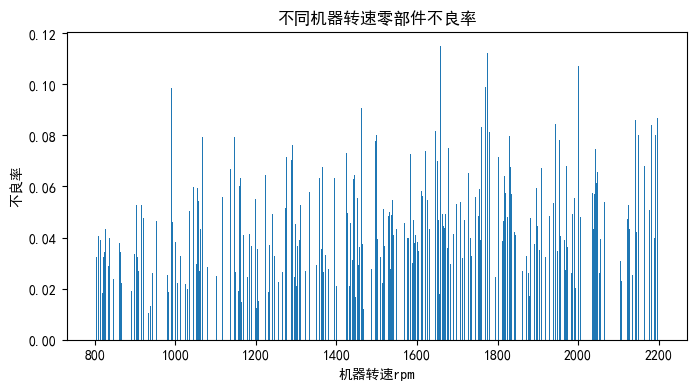

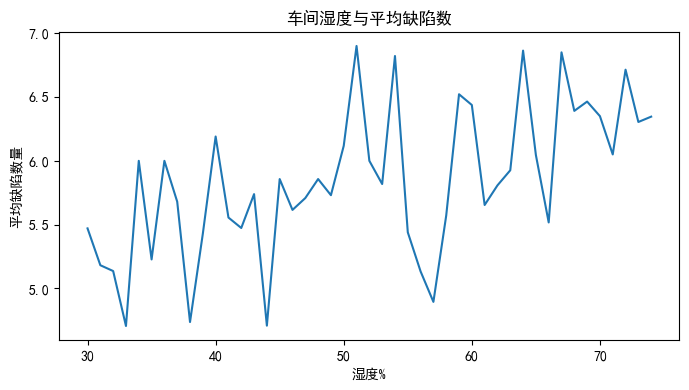

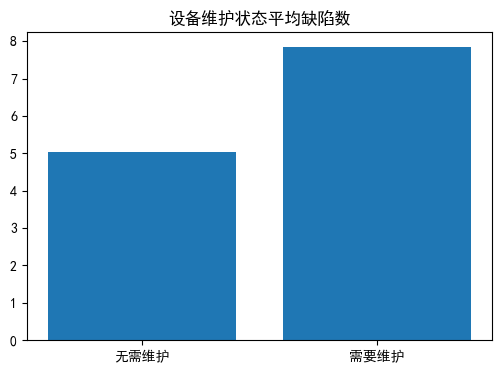


====分析结论====
整体零部件不良率：4.24%
1、高转速机器零部件不良率偏高
2、车间湿度升高，产品缺陷呈上升趋势
3、待维护设备产出零部件缺陷明显更多

业务建议：
①严格执行设备定期保养维护
②管控车间环境湿度，减少塑胶件瑕疵变形
③对高转速加工设备增加巡检频次


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 解决matplotlib中文乱码
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

# ==========生成模拟塑胶五金零部件生产数据==========
np.random.seed(42)
n = 1000

machine_speed_rpm = np.random.randint(800, 2200, n)
humidity_percent = np.random.randint(30, 75, n)
production_count = np.random.randint(80, 200, n)

# 转速越高、湿度越大，缺陷越多
defect_count = np.round(
    (machine_speed_rpm / 2000 * np.random.randint(2, 8, n))
    + (humidity_percent / 100 * np.random.randint(1, 6, n))
).astype(int)

maintenance_required = np.where(np.random.rand(n) > 0.7, 1, 0)
# 需要维护的设备缺陷额外增加
defect_count = np.where(maintenance_required == 1, defect_count + 3, defect_count)

df = pd.DataFrame({
    "machine_speed_rpm": machine_speed_rpm,
    "humidity_percent": humidity_percent,
    "production_count": production_count,
    "defect_count": defect_count,
    "maintenance_required": maintenance_required
})

# 导出数据集，用于上传GitHub
df.to_csv("manufacture_quality_data.csv", index=False)

# ==========1、数据探查与清洗==========
print("====数据基本信息====")
print(df.info())
print("\n====描述性统计====")
print(df.describe())
print("\n====缺失值统计====")
print(df.isnull().sum())

df = df.drop_duplicates()  # 删除重复行

# ==========2、指标计算==========
total_produce = df["production_count"].sum()
total_defect = df["defect_count"].sum()
overall_defect_rate = total_defect / total_produce
print(f"\n整体零部件不良率：{overall_defect_rate:.2%}")

# 按机器转速聚合
machine_defect = df.groupby("machine_speed_rpm").agg(
    total_output=("production_count", "sum"),
    total_defect=("defect_count", "sum")
).reset_index()
machine_defect["defect_rate"] = machine_defect["total_defect"] / machine_defect["total_output"]

# 湿度与平均缺陷
humidity_defect = df.groupby("humidity_percent")["defect_count"].mean()

# 维护状态平均缺陷
maintain_defect = df.groupby("maintenance_required")["defect_count"].mean()

# ==========3、绘图保存（savefig 必须在 show 前面）==========
# 图1：不同机器转速零部件不良率
plt.figure(figsize=(8, 4))
plt.bar(machine_defect["machine_speed_rpm"], machine_defect["defect_rate"])
plt.title("不同机器转速零部件不良率")
plt.xlabel("机器转速rpm")
plt.ylabel("不良率")
plt.savefig("speed_defect.png", dpi=300, bbox_inches="tight")
plt.show()

# 图2：车间湿度‑平均缺陷数量
plt.figure(figsize=(8, 4))
plt.plot(humidity_defect.index, humidity_defect.values)
plt.title("车间湿度与平均缺陷数")
plt.xlabel("湿度%")
plt.ylabel("平均缺陷数量")
plt.savefig("humidity_defect.png", dpi=300, bbox_inches="tight")
plt.show()

# 图3：设备维护状态平均缺陷数
plt.figure(figsize=(6, 4))
plt.bar(["无需维护", "需要维护"], maintain_defect.values)
plt.title("设备维护状态平均缺陷数")
plt.savefig("maintain_defect.png", dpi=300, bbox_inches="tight")
plt.show()

# ==========4、输出业务结论==========
print("\n====分析结论====")
print(f"整体零部件不良率：{overall_defect_rate:.2%}")
print("1、高转速机器零部件不良率偏高")
print("2、车间湿度升高，产品缺陷呈上升趋势")
print("3、待维护设备产出零部件缺陷明显更多")
print("\n业务建议：")
print("①严格执行设备定期保养维护")
print("②管控车间环境湿度，减少塑胶件瑕疵变形")
print("③对高转速加工设备增加巡检频次")
